In [2170]:
# Key Factors Influencing Demand:
# Demand for bus journeys is influenced by a range of factors, including holiday calendars, wedding seasons, long weekends, school vacations, and exam schedules. Additionally, regional holidays can affect different areas differently, and day-of-week effects further shape booking patterns. However, not all holidays significantly impact demand, making it a complex and non-trivial problem to model.

 
# The Hackathon Challenge:
# In this hackathon, your task is to develop a model that accurately forecasts demand for bus journeys. We will provide historical booking data from our platform, including the following:

# Seats booked: Historical demand data.
# Date of journey: The actual travel date.
# Date of issue: The date when the ticket was booked.
# Search data: The number of users searching for a particular journey date on a given booking date.
# Your goal:

# Predict the demand (total number of seats booked) for each journey at the route level, 15 days before the actual date of journey (doj).
# Example: For a route from Source City "A" to Destination City "B" with a date of journey (doj) on 30-Jan-2025, you need to predict the final seat count for this route on 16-Jan-2025, which is exactly 15 days prior to the journey date.

# You can download the training and testing datasets at the bottom of the Problem Statement.

# Evaluation Metric:
 

# The evaluation metric for this hackathon would be RMSE (Root Mean Squared Error).


# Public-Private Split
 

# Data Division:

# The test data for the competition is divided into two parts:
# Public Data (30%): Used for initial evaluation.
# Private Data (70%): Used for final evaluation.
# Scoring and Leaderboard Updates:

# During the competition, your initial responses will be checked and scored based on the Public Data.
# The scores obtained will be displayed on the Public Leaderboard, reflecting your progress in real-time.
# The leaderboard will reflect the participants’ standings in real-time based on the scoring metric mentioned in the problem statement.
# Final Rankings:

# Once the competition concludes, the Private Data will be used to compute the final scores.
# The final rankings will be based on the Private Score, which will be revealed only after the competition ends.

In [2171]:
!pip install holidays

# Importing Libraries

In [2172]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from scipy import stats

In [2173]:
train=pd.read_csv(r"C:\Users\vinod\ML\Redbus Hackathon\train.csv")
df=pd.read_csv(r"C:\Users\vinod\ML\Redbus Hackathon\transactions.csv")
test=pd.read_csv(r"C:\Users\vinod\ML\Redbus Hackathon\test_8gqdJqH.csv")

In [2174]:
route_stats = train.groupby(["srcid", "destid"])["final_seatcount"].agg(["mean", "std"]).reset_index()
route_stats.columns = ["srcid", "destid", "route_mean", "route_std"]
train = train.merge(route_stats, on=["srcid", "destid"], how="left")
test = test.merge(route_stats, on=["srcid", "destid"], how="left")


In [2175]:
df.sample(),df.shape

(                doj         doi  srcid  destid         srcid_region  \
 1769080  2024-09-21  2024-09-11      2       1  Maharashtra and Goa   
 
                destid_region srcid_tier destid_tier  cumsum_seatcount  \
 1769080  Maharashtra and Goa     Tier 1       Tier2               0.0   
 
          cumsum_searchcount  dbd  
 1769080               340.0   10  ,
 (2266100, 11))

In [2176]:
train.sample(),train.shape

(             doj  srcid  destid  final_seatcount   route_mean   route_std
 6057  2023-04-30     31       2           2592.0  1979.363095  886.924416,
 (67200, 6))

In [2177]:
test.sample(),test.shape

(            route_key         doj  srcid  destid  route_mean  route_std
 563  2025-01-07_46_18  2025-01-07     46      18  1891.77381  682.34993,
 (5900, 6))

# Pandas Profiling 

# Feature Engineering (Adding New columns)

In [2178]:
df['route_key'] = df['doj'].astype(str) + '_' + df['srcid'].astype(str) + '_' + df['destid'].astype(str)
train['route_key'] = train['doj'].astype(str) + '_' + train['srcid'].astype(str) + '_' + train['destid'].astype(str)

In [2179]:
df= pd.merge(train,df, on=['route_key','srcid','destid','doj'])
df.shape

(2083200, 15)

In [2180]:
df=df[df['dbd']>15]
df.shape

(1008000, 15)

In [2181]:
import holidays
df["doj"] = pd.to_datetime(df["doj"])
df["doi"] = pd.to_datetime(df["doi"])
indian_holidays = holidays.India(years=range(df['doj'].dt.year.min(), df['doj'].dt.year.max()+1))
df['is_holiday'] = df['doj'].isin(indian_holidays).astype(int)


In [2182]:
test["doj"] = pd.to_datetime(test["doj"])
indian_holidays = holidays.India(years=range(test['doj'].dt.year.min(), test['doj'].dt.year.max()+1))
test['is_holiday'] = test['doj'].isin(indian_holidays).astype(int)

In [2183]:

df["doj_month"] = df["doj"].dt.month
df["doj_week"] = df["doj"].dt.isocalendar().week.astype(int)
df["doj_day"] = df["doj"].dt.day
df["doj_dayofweek"] = df["doj"].dt.dayofweek
df["is_weekend"] = df["doj_dayofweek"].isin([5, 6]).astype(int)


In [2184]:
# test Data 
test["doj"] = pd.to_datetime(test["doj"])
test["doj_month"] = test["doj"].dt.month
test["doj_week"] = test["doj"].dt.isocalendar().week.astype(int)
test["doj_day"] = test["doj"].dt.day
test["doj_dayofweek"] = test["doj"].dt.dayofweek
test["is_weekend"] = test["doj_dayofweek"].isin([5, 6]).astype(int)


In [2185]:
df.groupby('is_weekend')['final_seatcount'].mean()

is_weekend
0    1904.626396
1    2244.487135
Name: final_seatcount, dtype: float64

In [2186]:
df['south_region']=np.where(
    (df['srcid_region'].isin(['Tamil Nadu','Maharshtra and Goa','Andhra Pradesh','Karnataka'])) |(df['destid_region'].isin(['Tamil Nadu','Maharshtra and Goa','Andhra Pradesh','Karnataka'])),1,0)

In [2187]:
south_region_srcid = df[df['south_region'] == 1]['srcid'].unique()
south_region_srcid

array([45, 46, 47,  9, 48,  5, 35, 44, 28, 43, 18, 42,  2,  3, 34, 26, 15,
       20, 39,  8,  6, 33], dtype=int64)

In [2188]:
south_region_destid = df[df['south_region'] == 1]['destid'].unique()
south_region_destid

array([46, 45, 47,  9, 48,  5, 44, 35, 28, 43, 18, 42, 15, 34,  2,  3, 26,
       20, 39,  6, 30,  8, 33, 10], dtype=int64)

In [2189]:
test['south_region']=np.where(
    (test['srcid'].isin(south_region_srcid)) | (test['destid'].isin(south_region_destid)),1,0)

In [2190]:
df['srcid_tier'].value_counts()

srcid_tier
Tier 1    594720
Tier2     312480
Tier 3     60480
Tier 4     40320
Name: count, dtype: int64

In [2191]:
for i in range(1,5):
  if(i==2):
    df['srcid_tier']=df['srcid_tier'].replace(f"Tier{i}",i)
    df['destid_tier']=df['destid_tier'].replace(f"Tier{i}",i)
  else:
    df['srcid_tier']=df['srcid_tier'].replace(f"Tier {i}",i)
    df['destid_tier']=df['destid_tier'].replace(f"Tier {i}",i)

In [2192]:
df['focus_city'] = np.where(
    (df['srcid_tier'] > 2) | (df['destid_tier'] > 2),1,0
)


In [2193]:
# test focus_city

In [2194]:
focus_city_srcid = df[df['focus_city'] == 1]['srcid'].unique()
focus_city_srcid

array([45, 28, 46, 47,  2, 26, 31, 15, 39, 36, 41,  6, 33,  4],
      dtype=int64)

In [2195]:
focus_city_destid = df[df['focus_city'] == 1]['srcid'].unique()
focus_city_destid

array([45, 28, 46, 47,  2, 26, 31, 15, 39, 36, 41,  6, 33,  4],
      dtype=int64)

In [2196]:
test['focus_city']=np.where((
    (test['srcid'].isin(focus_city_srcid)) | (test['destid'].isin(focus_city_destid))
),1,0)

In [2197]:
df=df.drop(['srcid_tier','destid_tier'],axis=1)

# DIkkat

In [2198]:
df['daily_seatcount']=df.groupby('route_key')['cumsum_seatcount'].diff().fillna(0)

In [2199]:
df['daily_search_count'] = df.groupby('route_key')['cumsum_searchcount'].diff().fillna(0)

In [2200]:
df = df.drop(['srcid_region', 'destid_region','doi'], axis=1)

In [2201]:
df.sample(5)

,doj,srcid,destid,final_seatcount,route_mean,route_std,route_key,cumsum_seatcount,cumsum_searchcount,dbd,is_holiday,doj_month,doj_week,doj_day,doj_dayofweek,is_weekend,south_region,focus_city,daily_seatcount,daily_search_count
1980344,2024-11-28,47,30,1980.0,1771.830357,480.627925,2024-11-28_47_30,5.0,270.0,28,0,11,48,28,3,0,1,0,0.0,35.0
1979174,2024-11-28,47,2,2290.0,1761.264881,546.453782,2024-11-28_47_2,10.0,680.0,20,0,11,48,28,3,0,1,0,5.0,55.0
1781019,2024-09-25,36,27,796.0,1348.458333,648.674745,2024-09-25_36_27,0.0,288.0,23,0,9,39,25,2,0,0,0,0.0,0.0
156864,2023-04-20,2,19,2025.0,1996.629464,680.560325,2023-04-20_2_19,10.0,200.0,26,0,4,16,20,3,0,0,0,5.0,35.0
421140,2023-07-14,6,47,965.0,1434.635417,532.882155,2023-07-14_6_47,0.0,10.0,25,0,7,28,14,4,0,1,1,0.0,0.0


In [2202]:
# Route- key used latter in the creation of prediction file

In [2203]:
route_key=test['route_key']

In [2204]:
# Encoding the route_key for both test and df dataframe
all_route_keys = pd.Index(df["route_key"]).union(test["route_key"])
combo_map = {k: i for i, k in enumerate(all_route_keys)}

# Apply the same mapping 
df["route_key"] = df["route_key"].map(combo_map)
test["route_key"] = test["route_key"].map(combo_map)


# Correlation

In [2205]:
from matplotlib import colormaps
list(colormaps)

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',
 'inferno_r',
 'plasma_r',
 'viri

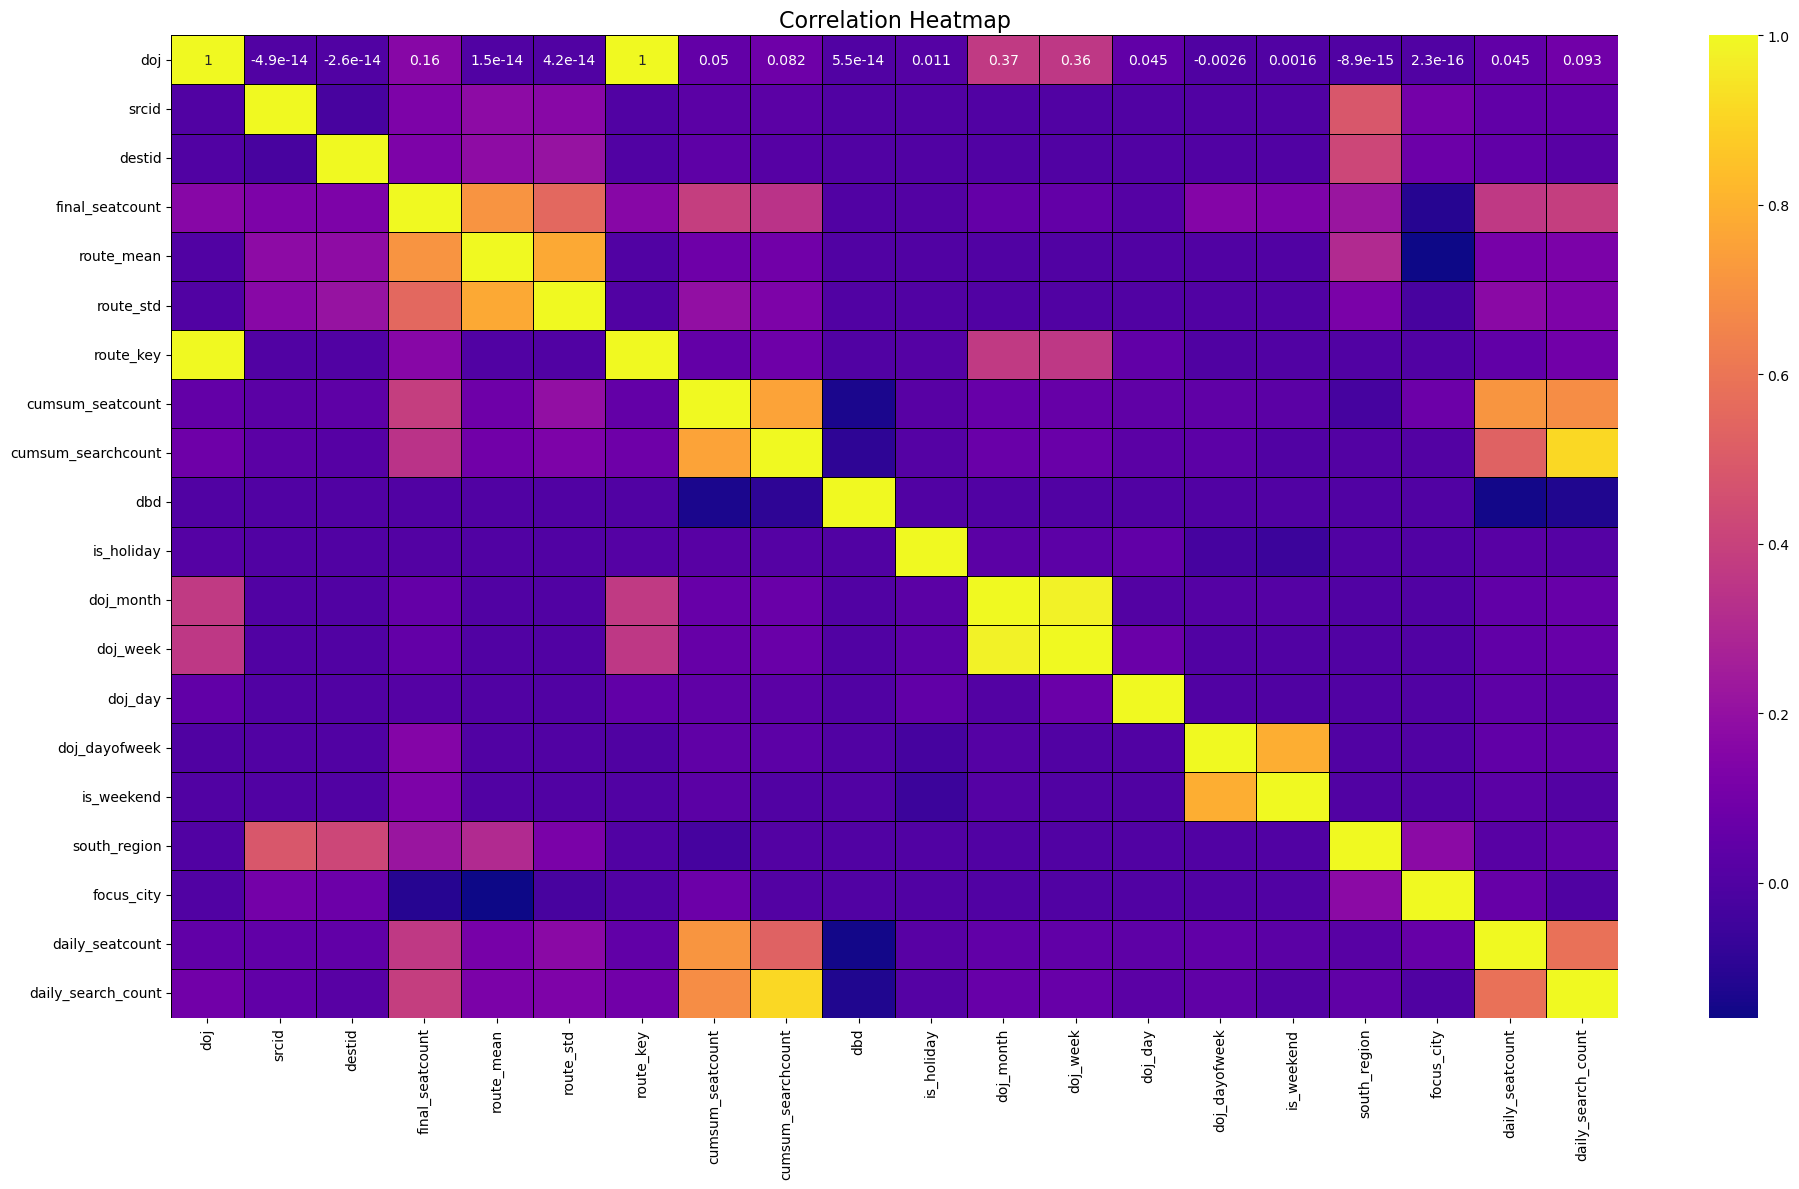

In [2206]:
corr = df.corr()

plt.figure(figsize=(20, 12))
sns.heatmap(corr, annot=True, cmap='plasma', linewidths=0.5, linecolor='black')
plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()


In [2207]:
df=df.drop(['dbd'],axis=1)

In [2208]:
group_cols = [
    'srcid', 'destid','doj_month']

In [2209]:
seat_agg = df.groupby(group_cols)['cumsum_seatcount'].mean().reset_index()
search_agg = df.groupby(group_cols)['cumsum_searchcount'].mean().reset_index()
daily_seat_agg = df.groupby(group_cols)['daily_seatcount'].mean().reset_index()
daily_search_agg = df.groupby(group_cols)['daily_search_count'].mean().reset_index()

In [2210]:

test = test.merge(seat_agg, on=group_cols, how='left')
test = test.merge(search_agg, on=group_cols, how='left')
test = test.merge(daily_seat_agg, on=group_cols, how='left')
test = test.merge(daily_search_agg, on=group_cols, how='left')

In [2211]:
# Optional: Filling any missing values 
test[['cumsum_seatcount', 'cumsum_searchcount', 'daily_seatcount', 'daily_search_count']] = test[['cumsum_seatcount', 'cumsum_searchcount', 'daily_seatcount', 'daily_search_count']].fillna(0)


In [2212]:
test = test[[col for col in df.columns if col in test.columns]]
test=test.drop(['doj'],axis=1)
df=df.drop(['doj'],axis=1)

In [2213]:
df1=df

In [2214]:
df2=df1

In [2215]:
df=df2

In [2216]:
test.shape,df.shape

((5900, 17), (1008000, 18))

In [2218]:
x=df.drop(['final_seatcount'],axis=1)
y=df['final_seatcount']
x.shape,y.shape

((1008000, 17), (1008000,))

In [2219]:
columns=x.columns
x.head()

,srcid,destid,route_mean,route_std,route_key,cumsum_seatcount,cumsum_searchcount,is_holiday,doj_month,doj_week,doj_day,doj_dayofweek,is_weekend,south_region,focus_city,daily_seatcount,daily_search_count
0,45,46,4218.64881,1069.31688,959,8.0,76.0,0,3,9,1,2,0,1,0,0.0,0.0
1,45,46,4218.64881,1069.31688,959,8.0,94.0,0,3,9,1,2,0,1,0,0.0,18.0
2,45,46,4218.64881,1069.31688,959,8.0,108.0,0,3,9,1,2,0,1,0,0.0,14.0
3,45,46,4218.64881,1069.31688,959,8.0,126.0,0,3,9,1,2,0,1,0,0.0,18.0
4,45,46,4218.64881,1069.31688,959,8.0,146.0,0,3,9,1,2,0,1,0,0.0,20.0


# Finalizing Test Data 

In [2220]:
test.columns,test.shape

(Index(['srcid', 'destid', 'route_mean', 'route_std', 'route_key',
        'cumsum_seatcount', 'cumsum_searchcount', 'is_holiday', 'doj_month',
        'doj_week', 'doj_day', 'doj_dayofweek', 'is_weekend', 'south_region',
        'focus_city', 'daily_seatcount', 'daily_search_count'],
       dtype='object'),
 (5900, 17))

In [2221]:
x.columns,x.shape

(Index(['srcid', 'destid', 'route_mean', 'route_std', 'route_key',
        'cumsum_seatcount', 'cumsum_searchcount', 'is_holiday', 'doj_month',
        'doj_week', 'doj_day', 'doj_dayofweek', 'is_weekend', 'south_region',
        'focus_city', 'daily_seatcount', 'daily_search_count'],
       dtype='object'),
 (1008000, 17))

In [2222]:
df_cols = set(df.columns)
test_cols = set(test.columns)
non_common_columns = df_cols.symmetric_difference(test_cols)
print(list(non_common_columns))


['final_seatcount']


In [2223]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

In [2224]:
x_scaled=scaler.fit_transform(x)
x_scaled

array([[9.36170213e-01, 9.57446809e-01, 8.47106967e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [9.36170213e-01, 9.57446809e-01, 8.47106967e-01, ...,
        0.00000000e+00, 0.00000000e+00, 6.05449041e-04],
       [9.36170213e-01, 9.57446809e-01, 8.47106967e-01, ...,
        0.00000000e+00, 0.00000000e+00, 4.70904810e-04],
       ...,
       [3.82978723e-01, 6.17021277e-01, 2.81619188e-01, ...,
        0.00000000e+00, 0.00000000e+00, 3.36360579e-04],
       [3.82978723e-01, 6.17021277e-01, 2.81619188e-01, ...,
        0.00000000e+00, 5.84795322e-02, 3.53178607e-03],
       [3.82978723e-01, 6.17021277e-01, 2.81619188e-01, ...,
        0.00000000e+00, 0.00000000e+00, 3.36360579e-04]])

In [2225]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,random_state=42,test_size=0.2)

In [2226]:
x_train

array([[2.76595745e-01, 6.17021277e-01, 3.42425704e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [9.78723404e-01, 5.74468085e-01, 3.72409516e-01, ...,
        1.00000000e+00, 0.00000000e+00, 7.56811302e-03],
       [1.27659574e-01, 7.44680851e-01, 3.27080629e-01, ...,
        0.00000000e+00, 2.33918129e-02, 1.07635385e-03],
       ...,
       [2.12765957e-02, 4.89361702e-01, 2.41957995e-01, ...,
        0.00000000e+00, 0.00000000e+00, 2.35452405e-03],
       [9.36170213e-01, 7.02127660e-01, 3.60278802e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [8.93617021e-01, 9.78723404e-01, 3.94037473e-01, ...,
        0.00000000e+00, 0.00000000e+00, 5.38176926e-04]])

# Training The model

In [2227]:
def train_model(X_train, y_train, X_val, y_val):
    model = LGBMRegressor(
        learning_rate=0.05,
        max_depth=24,
        num_leaves=74,
        feature_fraction=0.8,
        bagging_fraction=0.75,
        bagging_freq=8,
        n_estimators=5000,
        random_state=42,
        force_col_wise=True 
    )
    
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            early_stopping(stopping_rounds=100),
            log_evaluation(period=100)
        ]
    )
    
    return model

# Evaluating and plotting 

In [2228]:
def evaluate_model(model, X_val, y_val):
    val_preds = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    mae = mean_absolute_error(y_val, val_preds)
    r2 = r2_score(y_val, val_preds)
    
    print(f"\nValidation Metrics:")
    print(f"RMSE: {rmse:.4f}")
    
    plt.figure(figsize=(10, 8))
    feat_imp = pd.Series(model.feature_importances_, index=columns)
    feat_imp.nlargest(15).sort_values().plot(kind='barh')
    plt.title('Top 15 Feature Importances')
    plt.tight_layout()
    plt.savefig('Most_Important_features.png')
    plt.show()
    
    plt.figure(figsize=(10, 6))
    sns.regplot(x=y_val, y=val_preds, scatter_kws={'alpha':0.3})
    plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'k--')
    plt.xlabel('Actual Values (True Values)')
    plt.ylabel('Predicted Values (Predictions)')
    plt.title('Actual vs Predicted Values')
    plt.tight_layout()
    plt.savefig('Actual_Vs_Predicted.png')
    plt.show()
    
    # Plot error distribution
    errors = y_val - val_preds
    plt.figure(figsize=(10, 6))
    sns.histplot(errors, kde=True)
    plt.xlabel('Prediction Error')
    plt.title('Error Distribution')
    plt.tight_layout()
    plt.savefig('REDBUS_error.png')
    plt.show()

In [2229]:
model=train_model(x_train,y_train,x_test,y_test)

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.75, subsample=1.0 will be ignored. Current value: bagging_fraction=0.75
[LightGBM] [Warning] bagging_freq is set=8, subsample_freq=0 will be ignored. Current value: bagging_freq=8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.75, subsample=1.0 will be ignored. Current value: bagging_fraction=0.75
[LightGBM] [Warning] bagging_freq is set=8, subsample_freq=0 will be ignored. Current value: bagging_freq=8
[LightGBM] [Info] Total Bins 1510
[LightGBM] [Info] Number of data points in the train set: 806400, number of used features: 17
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.75, subsample=1.0 will be ignored. Current value: bagging_fraction=0.75
[LightGBM] [Warning] bagging_freq is set=8, subsample_freq=0 will be ignored. Current value: bagging_freq=8

Validation Metrics:
RMSE: 175.6606


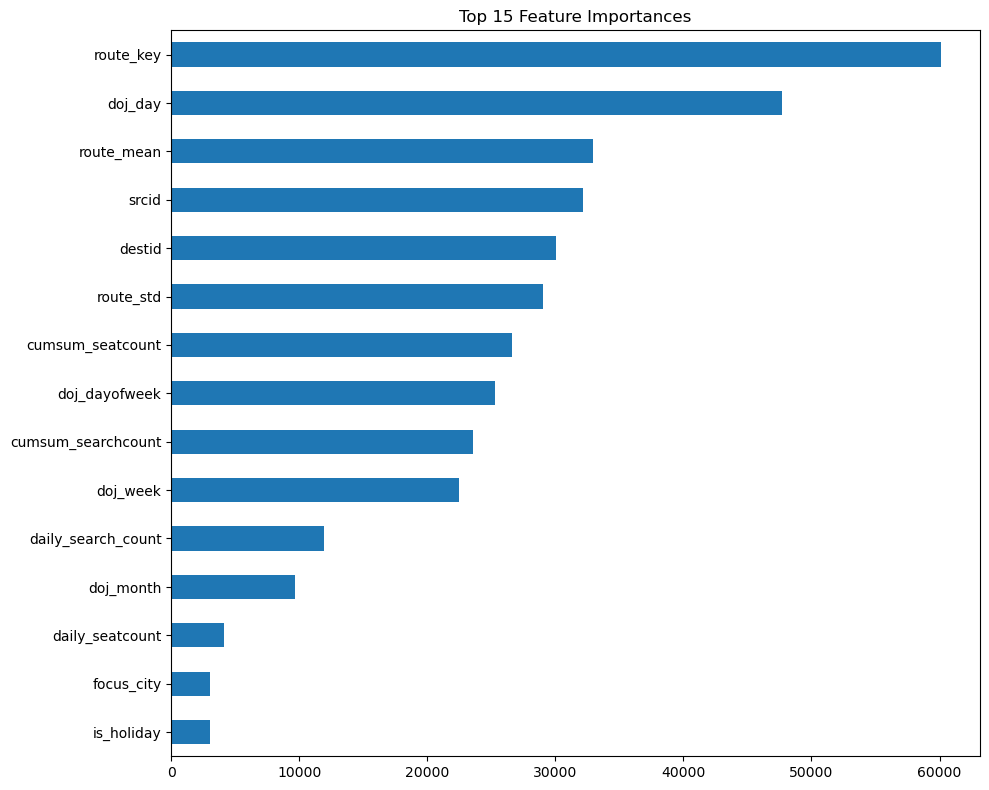

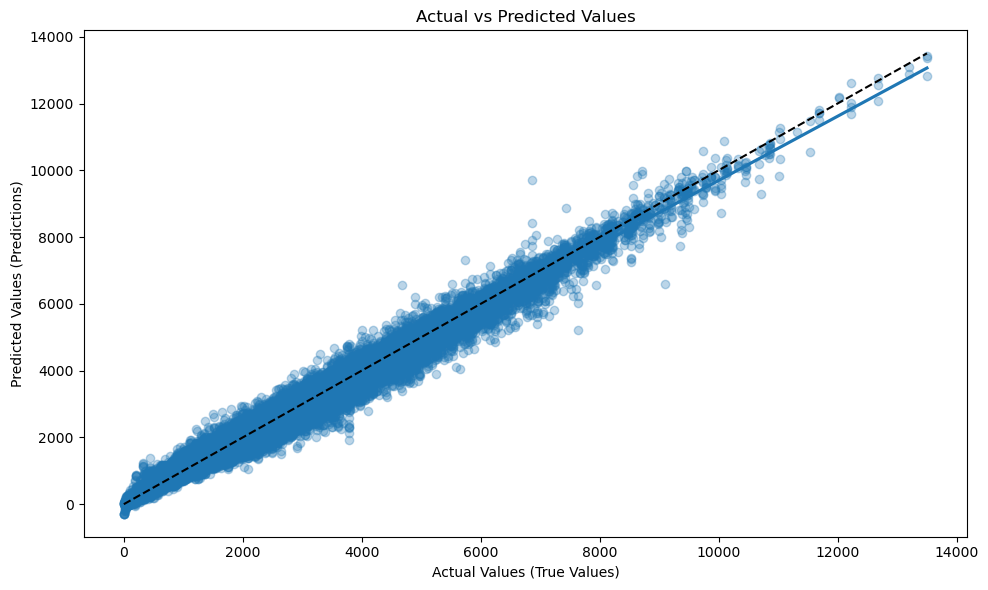

C:\Users\vinod\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


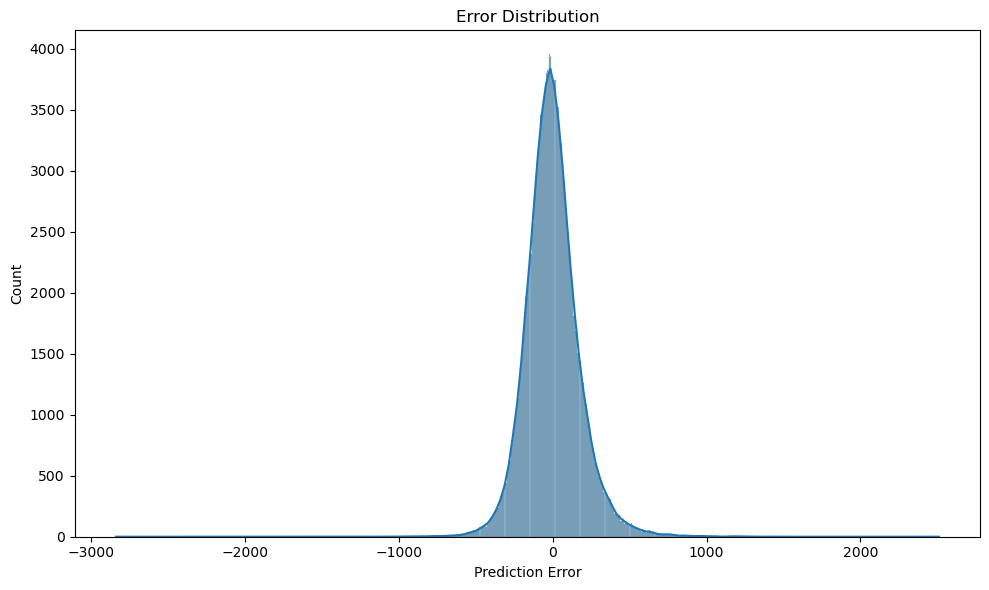

In [2230]:
evaluate_model(model,x_test,y_test)

# Predicting Test

In [2231]:
output_df = pd.DataFrame({
    'route_key': route_key,
    'final_seatcount': y_pred
})

# Save to CSV
output_df.to_csv('predictions1.csv', index=False)